<a href="https://colab.research.google.com/github/ismael-almazan/PNL/blob/main/embeddings_y_t_SNE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualización semántica de palabras utilizando embeddings y t-SNE

Explorar la representación semántica de palabras e identifica los diferentes dominios temáticos contenidos en el conjunto de datos proporcionado mediante la visualización 2D de embeddings de palabras. Realiza y define las actividades de preprocesamiento del texto (si lo crees necesario) para que fácilmente puedas identificar en la visualización lo siguiente:

1  ¿Cuántos dominios o grupos de datos puedes identificar visualmente en la gráfica?

2  ¿Cuáles son esos dominios?

Instrucciones adicionales:

*	Genera la gráfica 2D de los embeddings de palabras utilizando t-SNE.
*	Visualiza en la gráfica las palabras de cada uno de los puntos.
*	De manera manual, encierra aproximadamente con óvalos los grupos o dominios que hayas identificado.
*	Incluye la gráfica final y tus observaciones en el documento de entrega.


## Librerias requeridas

In [14]:
!pip install pandas nltk gensim scikit-learn matplotlib
!pip install gensim
import pandas as pd
import numpy as np
import nltk
import re


from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from gensim.models import Word2Vec

from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

import gensim.downloader as api

## Preprocesamiento

In [5]:
# Recursos para tokenizar y stopword
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to resolve LookupError

# Cargar el conjuto de datos
df = pd.read_csv('/content/sample_data/Ejercicios de Representación de textos - Embeddings.csv')
display(df.head())

# Eliminar stowords, toekinzar y normalizar a minusculas
stop_words = set(stopwords.words('spanish'))

def limpiar_texto(texto):
    # Minusculas
    texto = texto.lower()
    # Tokenizar
    tokens = word_tokenize(texto)
    # Stopwords
    tokens = [palabra for palabra in tokens if palabra not in stop_words]

    return tokens

# Aplicar funcion para limpiar
df["tokens"] = df["frase"].apply(limpiar_texto)
print(df["tokens"].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,frase
0,La ciberseguridad protege la información digit...
1,La inteligencia artificial transforma múltiple...
2,"El baloncesto combina velocidad, técnica y tra..."
3,El hardware y el software son complementarios ...
4,La democracia permite la participación ciudada...


0    [ciberseguridad, protege, información, digital...
1    [inteligencia, artificial, transforma, múltipl...
2    [baloncesto, combina, velocidad, ,, técnica, t...
3    [hardware, software, complementarios, computac...
4    [democracia, permite, participación, ciudadana...
Name: tokens, dtype: object


## Entrenar modelo

Se entrena el modelo con Wrod2Vec con los tokens limpios, se define una dimension de 100 para el embedding, un tamano de contexto de 5.

In [15]:
# Entrenar modelo Word2Vec

modelo = Word2Vec(
    sentences=df["tokens"],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)


# Extraer palabras y vectores
# Vocabulario aprendido
palabras = list(modelo.wv.index_to_key)

# Vectores
vectores = np.array([modelo.wv[palabra] for palabra in palabras])

print(f"Vocabulario: {len(palabras)}")
print(f"Vectores: {vectores.shape}")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [19]:
# Nodelo Word2Vec de google mas avanzado
modelo = api.load("word2vec-google-news-300")

palabras = []
vectores = []

palabras_unicas = set()

for lista_palabras in df["tokens"]:
    for palabra in lista_palabras:

        if palabra in modelo:
            palabras_unicas.add(palabra)

# convertir a lista
palabras = list(palabras_unicas)

# obtener vectores
vectores = np.array([modelo[palabra] for palabra in palabras])


## t-SNE

Text(0, 0.5, 'Dimensión 2')

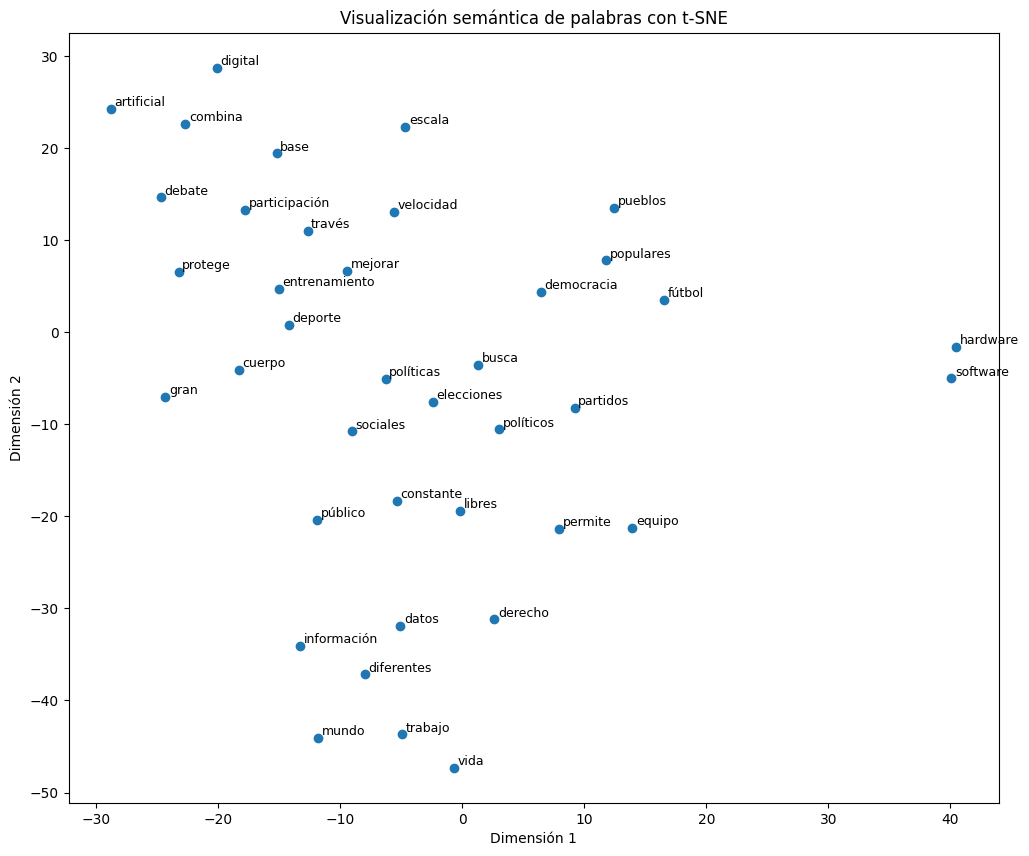

In [29]:
# modelo t-SNE
tsne = TSNE(n_components=2,
    perplexity=5)

# Aplicar reduccion dimensional
vectores_2d = tsne.fit_transform(vectores)


# Graficar

plt.figure(figsize=(12,10))
x = vectores_2d[:,0]
y = vectores_2d[:,1]
plt.scatter(x, y)

for i, palabra in enumerate(palabras):

    plt.text(x[i]+0.3, y[i]+0.3, palabra, fontsize=9)

plt.title("Visualización semántica de palabras con t-SNE")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")


La visualización de embeddings mediante t-SNE permitió representar en dos dimensiones las relaciones semánticas entre las palabras del conjunto de datos. Utilizando el modelo preentrenado Google Word2Vec, se observaron agrupamientos de términos con significados relacionados. En la gráfica se distinguen principalmente dominios asociados con tecnología, política y sociedad, y deporte, lo que evidencia que los embeddings generados con Word2Vec capturan similitudes semánticas entre palabras y permiten identificar temáticas presentes en el corpus.
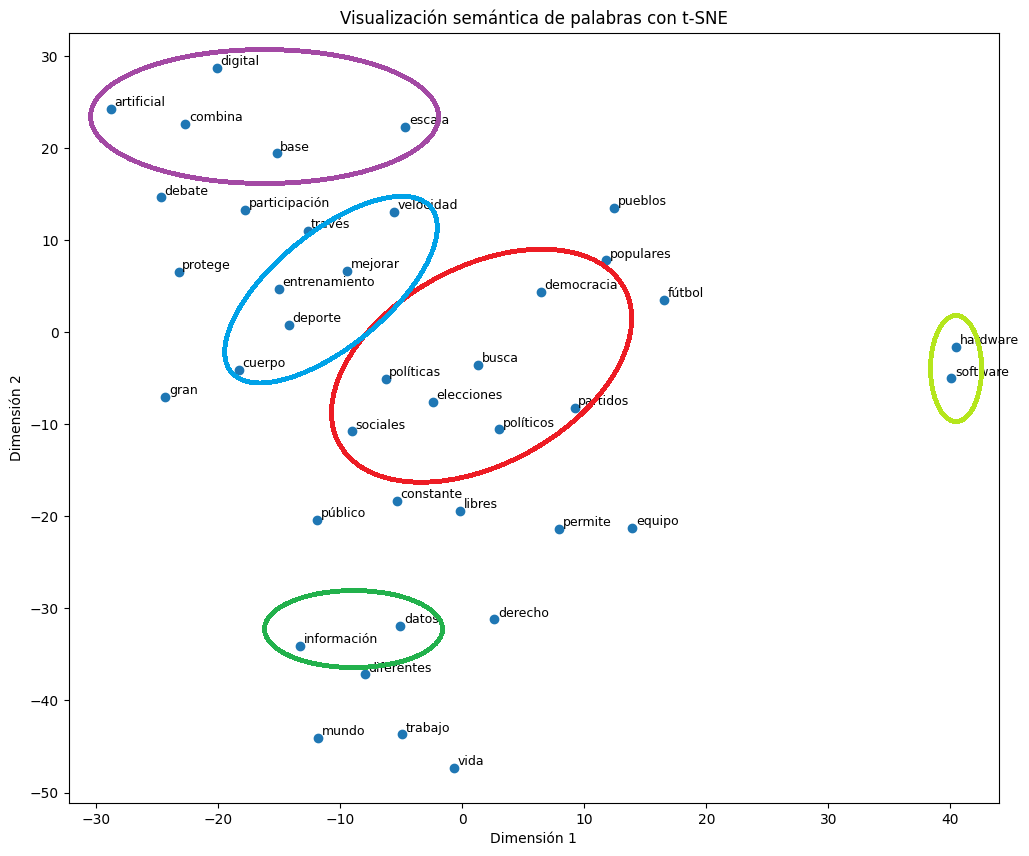